# Exploratory Data Analysis (EDA)
## Dataset: application_train

**Author:** Oknardo Tulung  
**LinkedIn:** https://www.linkedin.com/in/oknardo-tulung/ 
**GitHub:** https://github.com/oknardo/Home_Credit_Scorecard_Model

---

## 📌 Project Overview
This project focuses on performing a comprehensive Exploratory Data Analysis (EDA) on the `application_train` dataset from the Home Credit risk modeling case. The goal is to understand the underlying patterns, data quality, and key drivers related to loan default behavior.

---

## 🎯 Objectives
- Understand the structure and characteristics of the dataset  
- Identify data quality issues (missing values, outliers, inconsistencies)  
- Analyze the distribution of key variables  
- Explore relationships between features and the target variable (loan default)  
- Generate initial insights to support feature engineering and modeling  

---

## 🔍 Analysis Scope
The analysis includes:
- Univariate analysis (distribution of individual variables)  
- Bivariate analysis (relationship with TARGET)  
- Identification of class imbalance  
- Detection of anomalies and outliers  
- Initial business-driven interpretation of features  

---

## 🧠 Key Questions
- What factors differentiate default vs non-default customers?  
- How is income related to credit amount and repayment behavior?  
- Are there strong predictors within external scores (EXT_SOURCE)?  
- What patterns exist in demographic and financial features?  

---

## 🛠 Tools & Libraries
- Python  
- Pandas  
- NumPy  
- Matplotlib  
- Seaborn  

---

## 📊 Output
The output of this EDA will serve as:
- A foundation for feature engineering  
- Input for credit scoring models  
- Business insights for risk assessment  

# Importing Library

In [37]:
# Installation Library
!pip install seaborn


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [38]:
# Hide Warning
import warnings
warnings.filterwarnings('ignore')

# Importing Library
import pandas as pd
# Setting Pandas Row Display Max
pd.set_option('display.max_rows', None)

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


# Importing Dataset

In [39]:
# Dataset application_train
application_train = r'D:\Python\Projects\Project Scorecard Model Home Credit Indonesia\home-credit-default-risk\application_train.csv'
df_app_train = pd.read_csv(application_train)

# 1. About Dataset

The dataset consists of **307,511 observations** and **122 features**, representing individual loan application data. Each row corresponds to a single applicant, including financial, demographic, and supporting information.

The features can be grouped into several categories:
- **Target variable**: `TARGET`, indicating the default status  
- **Numerical features**: financial, temporal, and other quantitative variables  
- **Categorical features**: such as occupation type, family status, and contract type  
- **Binary indicators**: flags related to asset ownership and document submission  

Additionally, the dataset includes features with suffixes `_AVG`, `_MEDI`, and `_MODE`, which represent **aggregated characteristics of the applicant’s living environment**, such as building conditions and facilities.

In [40]:
df_app_train.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 122 columns):
 #    Column                        Dtype  
---   ------                        -----  
 0    SK_ID_CURR                    int64  
 1    TARGET                        int64  
 2    NAME_CONTRACT_TYPE            str    
 3    CODE_GENDER                   str    
 4    FLAG_OWN_CAR                  str    
 5    FLAG_OWN_REALTY               str    
 6    CNT_CHILDREN                  int64  
 7    AMT_INCOME_TOTAL              float64
 8    AMT_CREDIT                    float64
 9    AMT_ANNUITY                   float64
 10   AMT_GOODS_PRICE               float64
 11   NAME_TYPE_SUITE               str    
 12   NAME_INCOME_TYPE              str    
 13   NAME_EDUCATION_TYPE           str    
 14   NAME_FAMILY_STATUS            str    
 15   NAME_HOUSING_TYPE             str    
 16   REGION_POPULATION_RELATIVE    float64
 17   DAYS_BIRTH                    int64  
 18   DAYS_EMPLOYED

In [41]:
df_app_train.dtypes.value_counts()

float64    65
int64      41
str        16
Name: count, dtype: int64

# 2. Target Distribution

## 2.1 Default Rate

The target distribution shows that the majority of applicants **do not default (non-default)**.

- Total non-default (`TARGET = 0`): 282,686 (~91.9%)
- Total default (`TARGET = 1`): 24,825 (~8.1%)

This indicates that the dataset is **imbalanced**, where the number of default cases is significantly lower than non-default cases. This condition should be considered during the modeling stage, particularly in selecting appropriate evaluation metrics and handling class imbalance.

In [42]:
df_app_train['TARGET'].value_counts()

TARGET
0    282686
1     24825
Name: count, dtype: int64

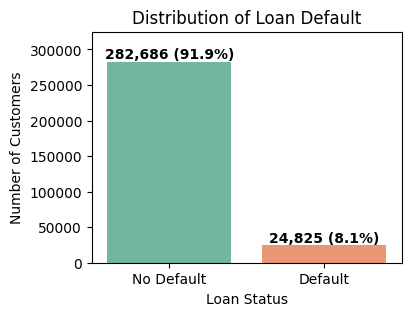

In [43]:
# Prepare data
target_df = (
    df_app_train['TARGET']
    .value_counts()
    .rename_axis('Target')
    .reset_index(name='Count')
    .assign(
        Percentage=lambda x: x['Count'] / x['Count'].sum() * 100,
        Target=lambda x: x['Target'].map({0: 'No Default', 1: 'Default'})
    )
)

# Plot
plt.figure(figsize=(4, 3))
ax = sns.barplot(
    data=target_df, x='Target', y='Count',
    hue='Target', palette='Set2', legend=False
)

plt.ylim(0, 325000)
plt.title('Distribution of Loan Default')
plt.xlabel('Loan Status')
plt.ylabel('Number of Customers')

# Add count and percentage labels on each bar
for i, row in target_df.iterrows():
    ax.text(
        i, row['Count'],
        f"{row['Count']:,} ({row['Percentage']:.1f}%)",
        ha='center', va='bottom', fontweight='bold'
    )

plt.show()

## 2.2 Contract Type

There are two types of contracts in the dataset:

- **Cash loans**: 278,232 (~90.5%)
- **Revolving loans**: 29,279 (~9.5%)

The majority of applicants use **cash loans**, indicating that this is the primary loan product in the dataset. This distribution difference may influence credit risk patterns and should be further analyzed in relation to the default rate.

In [44]:
df_app_train['NAME_CONTRACT_TYPE'].value_counts()

NAME_CONTRACT_TYPE
Cash loans         278232
Revolving loans     29279
Name: count, dtype: int64

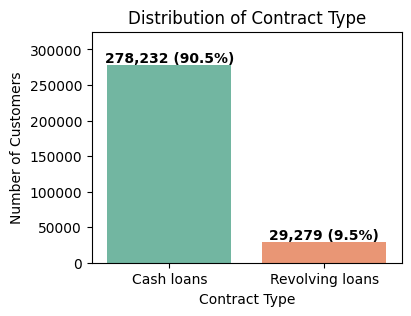

In [45]:
# Prepare data
contract_df = (
    df_app_train['NAME_CONTRACT_TYPE']
    .value_counts()
    .rename_axis('Contract_Type')
    .reset_index(name='Count')
    .assign(
        Percentage=lambda x: x['Count'] / x['Count'].sum() * 100
    )
)

# Plot
plt.figure(figsize=(4, 3))
ax = sns.barplot(
    data=contract_df, x='Contract_Type', y='Count',
    hue='Contract_Type', palette='Set2', legend=False
)

plt.ylim(0, 325000)
plt.title('Distribution of Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')

# Add count and percentage labels on each bar
for i, row in contract_df.iterrows():
    ax.text(
        i, row['Count'],
        f"{row['Count']:,} ({row['Percentage']:.1f}%)",
        ha='center', va='bottom', fontweight='bold'
    )

plt.show()

# 3. Missing Value Analysis

The missing value analysis is conducted to assess data quality and identify potential information contained within missing data.

The approach includes:
- **Measuring** the count and percentage of missing values for each feature  
- **Grouping** features based on their level of missingness  
- **Evaluating** the relationship between missing values and the *default rate*  

The results of this analysis are used to determine appropriate data handling strategies, including:
- **Dropping features** with very high and non-informative missing rates  
- **Imputing values** for features with moderate missingness  
- **Creating missing indicators** to capture potential risk patterns associated with missing data  

## 3.1 Missing Values Count
This section calculates the count and percentage of missing values for each feature,
along with its data type.

In [46]:
# Build missing value summary: count, percentage, and data type per feature
missing_df = (
    df_app_train.isnull()
    .agg(['sum', 'mean'])
    .T
    .reset_index()
    .rename(columns={
        'index': 'Feature',
        'sum': 'Missing_Count',
        'mean': 'Missing_Percentage'
    })
    .assign(
        Missing_Percentage=lambda x: (x['Missing_Percentage'] * 100).round(2),
        Data_Type=lambda x: x['Feature'].map(df_app_train.dtypes)
    )
    .sort_values(by='Missing_Percentage', ascending=False)
)

missing_df.head()

,Feature,Missing_Count,Missing_Percentage,Data_Type
48,COMMONAREA_AVG,214865.0,69.87,float64
62,COMMONAREA_MODE,214865.0,69.87,float64
76,COMMONAREA_MEDI,214865.0,69.87,float64
84,NONLIVINGAPARTMENTS_MEDI,213514.0,69.43,float64
70,NONLIVINGAPARTMENTS_MODE,213514.0,69.43,float64


## 3.2 Default Rate to Missing Features
This section examines whether missing values carry predictive signal by comparing
the default rate between rows where data is present versus missing.

In [47]:
# Create a lookup dictionary from missing_df for O(1) access per feature
missing_pct_lookup = missing_df.set_index('Feature')['Missing_Percentage'].to_dict()

# Build a summary DataFrame for all features that have missing values
missing_default_rate = pd.DataFrame([
    {
        'Feature': col,
        # Percentage of rows where this feature is NaN
        'Missing_Percentage (%)': missing_pct_lookup[col],
        # Average TARGET (default rate) among rows where col has a value
        'Default Rate (Not Missing) (%)': df_app_train.loc[df_app_train[col].notna(), 'TARGET'].mean() * 100,
        # Average TARGET (default rate) among rows where col is NaN
        'Default Rate (Missing) (%)': df_app_train.loc[df_app_train[col].isna(), 'TARGET'].mean() * 100,
    }
    for col in all_missing_features 
]).set_index('Feature').round(2)   

missing_default_rate

,Missing_Percentage (%),Default Rate (Not Missing) (%),Default Rate (Missing) (%)
Feature,,,
COMMONAREA_AVG,69.87,6.91,8.57
COMMONAREA_MODE,69.87,6.91,8.57
COMMONAREA_MEDI,69.87,6.91,8.57
NONLIVINGAPARTMENTS_MEDI,69.43,6.91,8.58
NONLIVINGAPARTMENTS_MODE,69.43,6.91,8.58
NONLIVINGAPARTMENTS_AVG,69.43,6.91,8.58
FONDKAPREMONT_MODE,68.39,6.89,8.62
LIVINGAPARTMENTS_AVG,68.35,6.89,8.62
LIVINGAPARTMENTS_MEDI,68.35,6.89,8.62


## Key Findings & Handling Strategy

Most missing features show **higher default rate when missing**, meaning missingness itself
is a risk signal worth preserving via missing indicators. A few features show the opposite
pattern — missing rows have **lower default rate** — but remain informative nonetheless.

---

### Handling Strategy

**Numerical Features — Median Impute**
- **> 50% missing**: All building features (`APARTMENTS_*`, `FLOORS*`, `LIVINGAREA_*`, `LANDAREA_*`, etc.) → Missing Indicator + Median Impute
- **10–50% missing**: `EXT_SOURCE_1`, `EXT_SOURCE_3`, `AMT_REQ_CREDIT_BUREAU_*` → Missing Indicator + Median Impute
- **< 1% missing**: `EXT_SOURCE_2`, `AMT_GOODS_PRICE` → Simple Median Impute

> ⚠️ `OWN_CAR_AGE` — missing likely means *no car*, impute with `0` or derive `HAS_CAR` flag from `FLAG_OWN_CAR`.

**Categorical Features — Mode Impute**
- **> 50% missing**: `FONDKAPREMONT_MODE`, `WALLSMATERIAL_MODE`, `HOUSETYPE_MODE`, `EMERGENCYSTATE_MODE` → Missing Indicator + Mode/`'Unknown'` Impute
- **10–50% missing**: `OCCUPATION_TYPE` → Missing Indicator + Mode/`'Unknown'` Impute
- **< 1% missing**: `NAME_TYPE_SUITE` → Simple Mode Impute

---

### Note: Building Features (`_AVG`, `_MODE`, `_MEDI`)
Features such as `APARTMENTS_AVG`, `FLOORSMAX_MODE`, `LIVINGAREA_MEDI` are
**normalized statistical aggregations** describing the building where the client lives,
where `_AVG` = mean, `_MODE` = modus, and `_MEDI` = median of the same property.

Since they describe the same underlying property from three angles, they tend to be
highly correlated. Consider **dropping** `_MODE` and `_MEDI` variants and retaining
only `_AVG` per property group to reduce dimensionality, or apply **PCA** during feature engineering.

---

### Features for Further Analysis
- `EXT_SOURCE_1/2/3` — external credit scores; strong predictors of default risk
- `AMT_REQ_CREDIT_BUREAU_*` — credit bureau enquiry frequency; largest positive gap (+2.62%)
- `OCCUPATION_TYPE` — reversed pattern (missing = lower risk); worth analyzing default rate per category
- `DEF/OBS_CNT_SOCIAL_CIRCLE` — social circle default behavior; largest reversed gap (-4.56%)
- `OWN_CAR_AGE` — needs domain-aware imputation before use
- **Building features** (`APARTMENTS_*`, `FLOORS*`, `LIVINGAREA_*`, etc.) — assess inter-group
  correlation and determine which suffix (`_AVG`, `_MODE`, `_MEDI`) to retain,
  or whether dimensionality reduction is more appropriate

# 4. Univariate Analysis
Univariate analysis examines each feature independently to understand its distribution,
central tendency, and spread. This serves as the foundation before exploring relationships
between features and the target variable.

The approach includes:
- **Describing** numerical features through summary statistics (mean, median, std, min, max)
- **Describing** categorical features through frequency and unique value counts
- **Identifying** potential anomalies, skewness, or irregular distributions

---

## 4.1 Statistical Descriptive


### 4.1.1 Numerical Features

In [48]:
df_app_train.describe().T

,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,307511.0,278180.518577,102790.175348,1.000020e+05,189145.500000,278202.000000,367142.500000,4.562550e+05
TARGET,307511.0,0.080729,0.272419,0.000000e+00,0.000000,0.000000,0.000000,1.000000e+00
CNT_CHILDREN,307511.0,0.417052,0.722121,0.000000e+00,0.000000,0.000000,1.000000,1.900000e+01
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,2.565000e+04,112500.000000,147150.000000,202500.000000,1.170000e+08
AMT_CREDIT,307511.0,599025.999706,402490.776996,4.500000e+04,270000.000000,513531.000000,808650.000000,4.050000e+06
AMT_ANNUITY,307499.0,27108.573909,14493.737315,1.615500e+03,16524.000000,24903.000000,34596.000000,2.580255e+05
AMT_GOODS_PRICE,307233.0,538396.207429,369446.460540,4.050000e+04,238500.000000,450000.000000,679500.000000,4.050000e+06
REGION_POPULATION_RELATIVE,307511.0,0.020868,0.013831,2.900000e-04,0.010006,0.018850,0.028663,7.250800e-02
DAYS_BIRTH,307511.0,-16036.995067,4363.988632,-2.522900e+04,-19682.000000,-15750.000000,-12413.000000,-7.489000e+03
DAYS_EMPLOYED,307511.0,63815.045904,141275.766519,-1.791200e+04,-2760.000000,-1213.000000,-289.000000,3.652430e+05


#### Key Findings

**Target & Class Imbalance**  
Mean of `TARGET` is 0.08 — only **8% of applicants defaulted**, confirming a heavily imbalanced dataset.
This must be addressed during modeling (e.g. oversampling, class weighting).

**Anomalies Detected**
- `DAYS_EMPLOYED` max = **365,243** — clearly an outlier/encoding error, likely used to flag pensioners or unemployed. Requires special handling before modeling.
- `AMT_INCOME_TOTAL` max = **117,000,000** — extreme outlier, likely needs capping.
- `CNT_CHILDREN` max = **19** and `CNT_FAM_MEMBERS` max = **20** — suspicious, worth investigating.

**Skewed Distributions**
- `AMT_INCOME_TOTAL`, `AMT_CREDIT`, `AMT_GOODS_PRICE` — large gap between mean and median indicates right skew.
- `OBS/DEF_CNT_SOCIAL_CIRCLE` — median = 0 with large max (348), heavily right-skewed.
- `AMT_REQ_CREDIT_BUREAU_*` — median = 0 across most timeframes, majority of applicants had no enquiries.

**Near-Zero Variance Features**  
`FLAG_MOBIL` (mean = 0.9999) and `FLAG_CONT_MOBILE` (mean = 0.998) are almost constant —
likely **low predictive value**, consider dropping during feature selection.

**Days Features (Negative Values)**  
`DAYS_BIRTH`, `DAYS_REGISTRATION`, `DAYS_ID_PUBLISH`, `DAYS_LAST_PHONE_CHANGE` are all negative
by design (days relative to application date). Consider converting to absolute values or age in years
for interpretability.

**External Credit Scores (`EXT_SOURCE_1/2/3`)**  
All three are normalized between 0–1 with mean ~0.50 — well-distributed and likely strong predictors.
Worth prioritizing in feature importance analysis.

**Building Features (`_AVG`, `_MODE`, `_MEDI`)**  
Mean and median values are nearly identical across all three suffix variants per property,
confirming high redundancy. Retaining only `_AVG` per group is sufficient.

### 4.1.2 Categorical Features

In [49]:
cat_features = df_app_train.select_dtypes(include='object').columns

cat_summary = pd.DataFrame({
    'Unique_Values': df_app_train[cat_features].nunique(),
    'Most_Frequent': df_app_train[cat_features].apply(lambda x: x.value_counts().index[0]),
    'Frequency': df_app_train[cat_features].apply(lambda x: x.value_counts().iloc[0]),
    'Frequency_%': df_app_train[cat_features].apply(
        lambda x: (x.value_counts().iloc[0] / x.count() * 100).round(2)
    )
})

cat_summary

,Unique_Values,Most_Frequent,Frequency,Frequency_%
NAME_CONTRACT_TYPE,2,Cash loans,278232,90.48
CODE_GENDER,3,F,202448,65.83
FLAG_OWN_CAR,2,N,202924,65.99
FLAG_OWN_REALTY,2,Y,213312,69.37
NAME_TYPE_SUITE,7,Unaccompanied,248526,81.16
NAME_INCOME_TYPE,8,Working,158774,51.63
NAME_EDUCATION_TYPE,5,Secondary / secondary special,218391,71.02
NAME_FAMILY_STATUS,6,Married,196432,63.88
NAME_HOUSING_TYPE,6,House / apartment,272868,88.73
OCCUPATION_TYPE,18,Laborers,55186,26.14


#### Key Findings

**Dominant Categories (High Concentration)**
- `NAME_CONTRACT_TYPE` — 90.48% are *Cash loans*, very little variation.
- `NAME_HOUSING_TYPE` — 88.73% live in *House/apartment*.
- `HOUSETYPE_MODE` — 98.23% are *block of flats*, near-constant → **low predictive value, consider dropping**.
- `EMERGENCYSTATE_MODE` — 98.56% are *No* → near-constant, **consider dropping**.

**Gender Imbalance**
- `CODE_GENDER` has 3 unique values (likely includes *XNA*) — 65.83% female.
  XNA category should be investigated and handled before modeling.

**Occupation & Organization Type**
- `OCCUPATION_TYPE` has 18 categories with *Laborers* as the most frequent (26.14%) —
  wide variety, consider grouping rare categories.
- `ORGANIZATION_TYPE` has 58 categories — highest cardinality among categorical features,
  may need grouping or encoding strategy (e.g. frequency/target encoding).

**Marital & Education Status**
- `NAME_FAMILY_STATUS` — 63.88% *Married*, relatively balanced across other categories.
- `NAME_EDUCATION_TYPE` — 71.02% *Secondary/secondary special*, lower education dominates.

**Features Worth Further Analysis**
- `CODE_GENDER`, `NAME_INCOME_TYPE`, `OCCUPATION_TYPE`, `ORGANIZATION_TYPE` —
  sufficient category variation to explore default rate differences across groups.
- `FONDKAPREMONT_MODE` and `WALLSMATERIAL_MODE` — moderate variation,
  worth checking default rate per category before deciding to drop.

# 5. Bivariate Analysis